In [1]:
#generating fft-color images of first three sites of hp library sent by guo-teng
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import matplotlib.image as mpimg
#Import modules
import matplotlib.pyplot as plt
import numpy as np
from os import path
import tifffile
import time

In [2]:
import torch
#detrend timeseries centers the oscillation around 0 and aims to remove the DC component of the FFT (without truncation)
def detrend_timeseries(Y):
    start_time = time.time()
    T, H, W = Y.shape
    
    #make the time-axis to use in the fit
    t = torch.arange(T, dtype=Y.dtype, device=Y.device) #offers option for on-GPU is you have your array there
    
    # Compute sums for computing the coefficients
    sum_t = t.sum()
    sum_t2 = (t ** 2).sum()
    n = T
    
    sum_y = Y.sum(dim=0)
    sum_ty = (Y * t.view(-1, 1, 1)).sum(dim=0)
    
    # Compute coefficients a (slope) and b (intercept)
    denominator = sum_t2 - (sum_t ** 2) / n
    a = (sum_ty - (sum_t * sum_y) / n) / denominator
    b = (sum_y - a * sum_t) / n
    
    # Calculate and subtract the trend
    trend = a.unsqueeze(0) * t.view(-1, 1, 1) + b.unsqueeze(0)
    print("--- %s seconds ---" % (time.time() - start_time))
    del t, sum_t, sum_t2, n, sum_y, sum_ty, denominator, a, b
    return Y - trend


In [3]:
import os
p = r"F:\20260905_Hp-lib-v2_DROPBOX\test" #replace with your dir of files
files = os.listdir(r"F:\20260905_Hp-lib-v2_DROPBOX\test")
files

['C3-s0-Mosaic001.ome.tif',
 'C3-s1-Mosaic001.ome.tif',
 'C3-s2-Mosaic001.ome.tif',
 'freq_color',
 'freq_stacks',
 'masks',
 'registered']

In [5]:
dirs= ['freq_stacks']
for d in dirs:
    if not os.path.exists(os.path.join(p,d)):
            os.makedirs(os.path.join(p,d))

for f in files:
    if f.endswith('.tif'):
        point_name = f.split('-')[1]
        im = tifffile.imread(os.path.join(p,f))
        im_minD = im[:,2,:,:]
        del im
        c_im_torch = torch.from_numpy(im_minD.astype('float32')) #convert im to tensor
        c_im_c=detrend_timeseries(c_im_torch)
        fft_c = torch.fft.rfft(c_im_c,axis=0).detach().numpy()[0:40] #just getting first 40 frames for better visualization down the line
        ps=np.abs(fft_c) 
        

        tifffile.imwrite(os.path.join(p,'freq_stacks',"{}_FFT.tiff".format(point_name)),ps)
        ps_norm = ps/np.sum(ps,axis=0)
        del ps
        tifffile.imwrite(os.path.join(p,'freq_stacks',"{}_FFT_norm.tiff".format(point_name)),ps_norm)
        del ps_norm

--- 3.856914758682251 seconds ---
--- 3.294544219970703 seconds ---
--- 4.234728574752808 seconds ---


# Color code image outputs

In [4]:
def temporalColorCode(img,cmap='turbo',proj='max'):
    slices,x,y=img.shape
    cc=plt.colormaps.get_cmap(cmap).resampled(slices)(range(slices))
    CC=np.broadcast_to(cc,(x,y,slices,4)).swapaxes(0,2)[:,:,:,0:3].T
    outstack=((CC*(img.T).swapaxes(0,1)).T)
    if proj=='max':
        out=(outstack.max(axis=0)).swapaxes(0,1)
    elif proj=='sum':
        out=(outstack.sum(axis=0)).swapaxes(0,1)
    return out

Freq range in mHz =  [2.770083102493075, 7.202216066481995]
Saved s0_FFT_color_5-13
Saved s0_FFT_norm_color_5-13
Saved s1_FFT_color_5-13
Saved s1_FFT_norm_color_5-13
Saved s2_FFT_color_5-13
Saved s2_FFT_norm_color_5-13


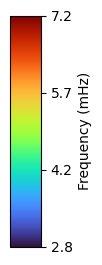

In [8]:
fr_rate = 5
num_frames = 361
fft_start = 5 #Set frame range for start and end of colorbar (bins, not mHz)
fft_end = 13 #this range determined from looking in Fiji at FFT stacks and seeing where the cells are
gamma = 0.4 #brightness boost for the normalized pngs

mHz_conv = ((1/fr_rate)/num_frames)*1000
freq_range = [fft_start* mHz_conv, fft_end * mHz_conv]
print("Freq range in mHz = ", freq_range)

stack_dir = os.path.join(p,'freq_stacks')
color_dir = os.path.join(p,'freq_color')
png_dir = os.path.join(color_dir,'png')
os.makedirs(png_dir, exist_ok=True)

for f in sorted(os.listdir(stack_dir)):
    if not (f.endswith('_FFT.tiff') or f.endswith('_FFT_norm.tiff')):
        continue
    name = f.replace('.tiff','') + "_color_{}-{}".format(fft_start,fft_end)
    ps = tifffile.imread(os.path.join(stack_dir,f))
    t = temporalColorCode(ps[fft_start:fft_end,:,:])
    del ps
    tifffile.imwrite(os.path.join(color_dir, name + '.tiff'), t) #RGB stack, openable in fiji

    # if f.endswith('_FFT_norm.tiff'):
    #     rgb = t ** gamma #already normalized, gamma increases brightness
    # else:
    #     rgb = t / t.max() #PS, high-amplitude cells pop out. normalize to [0,1] for RGB display

    #plt.imsave(os.path.join(png_dir, name + '.png'), np.clip(rgb,0,1))
    lo_pct, hi_pct = 1, 99.5   # raise lo_pct for a darker background, lower hi_pct for brighter cells
    gamma = 0.8                # <1 lifts the midtones

    lo, hi = np.percentile(t, [lo_pct, hi_pct])   # over all of R, G and B together, so hues stay the same
    rgb = np.clip((t - lo) / (hi - lo), 0, 1) ** gamma
    plt.imsave(os.path.join(png_dir, name + '.png'), rgb)


    print('Saved', name)

#colorbar as a separate file (same range for all images above)
fig, cax = plt.subplots(figsize=(0.4, 3))
sm = ScalarMappable(cmap='turbo', norm=Normalize(vmin=freq_range[0], vmax=freq_range[-1]))
sm.set_array([])
cbar_ticks = np.linspace(freq_range[0],freq_range[1],4)
cbar = fig.colorbar(sm, cax=cax, ticks=cbar_ticks,format='{x:.1f}')
cbar.set_label('Frequency (mHz)')
fig.savefig(os.path.join(png_dir, "colorbar_{}-{}.png".format(fft_start,fft_end)), dpi=300, bbox_inches='tight')
plt.show()